Быков Владимир 465327

In [279]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as image

Степенной метод используется для того, чтобы найти только доминирующее сингулярное значение и соответствующие ему векторы 𝑢 и 𝑣. Это означает, что степенной метод не вычисляет все сингулярные значения, а фокусируется лишь на одном — самом большом, и за счет итераций приближает решение. Поэтому его целью является сжатие вычислений и нахождение лишь первой компоненты

Значит число итераций в степенном методе определяет точность вычисления только одной компоненты

Не используем полное число компонент тк полное сингулярное разложение (SVD) для матрицы изображения может быть избыточным, так как многие компоненты будут иметь незначительное значение и не будут вносить существенного вклада в представление данных. В нашем случае, часто бывает достаточно только нескольких компонент, чтобы реконструировать изображение с хорошим качеством.

Соответственно, число компонент, равное размеру изображения, относится к полному разложению всех сингулярных значений и векторов, но это гораздо более ресурсоемко и часто избыточно для практических задач, таких как сжатие данных или аппроксимация.

| `max_iter`                      | Влияние                                                                                 |
| ------------------------------- | --------------------------------------------------------------------------------------- |
| **Малое значение** (напр. ≤ 5)  | Быстро, но может не сойтись. Полученные сингулярные векторы могут быть неточны.         |
| **Умеренное значение** (20–100) | Хороший компромисс между точностью и временем работы. В большинстве случаев достаточно. |
| **Слишком большое значение**    | Более точные результаты, но могут быть избыточны и замедляют работу.                    |


In [280]:
def power_method_svd(A, num_components=10, max_iter=50, tol=1e-10):
    """
    Вычисляет первые `num_components` сингулярных компонент с помощью степенного метода.
    Возвращает:
        U: (m, num_components) — левые сингулярные векторы
        S: (num_components,) — сингулярные значения
        VT: (num_components, n) — правые сингулярные векторы
    """
    m, n = A.shape
    U = np.zeros((m, num_components))
    S = np.zeros(num_components)
    VT = np.zeros((num_components, n))
    
    A_current = A.copy()
    
    for i in range(num_components):
        u, sigma, v = _power_iteration(A_current, max_iter, tol)
        U[:, i] = u
        S[i] = sigma
        VT[i, :] = v
        
        # Дефляция
        A_current -= sigma * np.outer(u, v)
        
    return U, S, VT

def _power_iteration(A, max_iter, tol):
    """Степенной метод для одной компоненты."""
    m, n = A.shape
    v = np.random.rand(n)
    v /= np.linalg.norm(v)
    
    for i in range(max_iter):
        u = A @ v
        u /= np.linalg.norm(u)
        v_new = A.T @ u
        v_new /= np.linalg.norm(v_new)
        
        if np.linalg.norm(v_new - v) < tol:
            break #если попали в необходимую точность, то прерываем, 
        #в противном случае отграничиваемся заданным ограничением по итерации
        v = v_new
    
    sigma = np.linalg.norm(A @ v)
    return u, sigma, v

In [281]:
def calculate_reconstruction_error(original, restored):
    """
    Вычисляет относительную ошибку в норме Фробениуса.
    """
    error = np.linalg.norm(original - restored, ord='fro')
    norm_original = np.linalg.norm(original, ord='fro')
    return error / norm_original * 100  # В процентах

In [282]:
def read_from_shrinked(U, S, VT, k):
    return (U[:,:k] @ np.diag(S[:k])) @ VT[:k]

| Параметр             | За что отвечает                                                                                                                                                       |
| -------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`num_components`** | Сколько **первых (крупнейших)** сингулярных компонент (троек $u_i, \sigma_i, v_i$) мы хотим получить. Это число **SVD-ранга**, до которого мы приближаем.             |
| **`max_iter`**       | Сколько **итераций** допускается на **одну компоненту** при её поиске методом степенных итераций. То есть это ограничение на **внутреннюю точность каждой итерации**. |


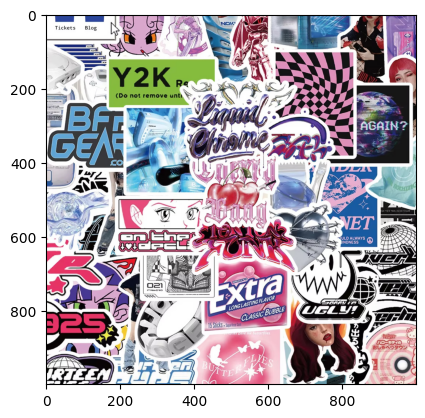

max_iter=1: средняя ошибка 33.52159971349774%
max_iter=1: ошибка R 32.63%
max_iter=1: ошибка G 35.44%
max_iter=1: ошибка B 32.50%


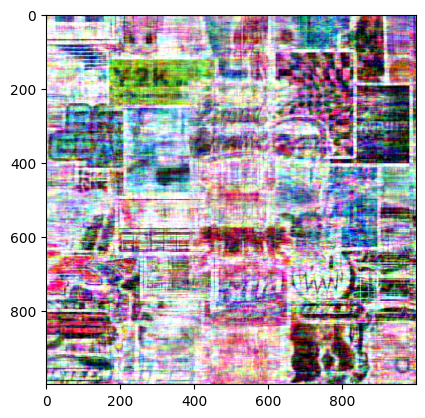

max_iter=5: средняя ошибка 23.802106463308235%
max_iter=5: ошибка R 23.49%
max_iter=5: ошибка G 25.09%
max_iter=5: ошибка B 22.83%


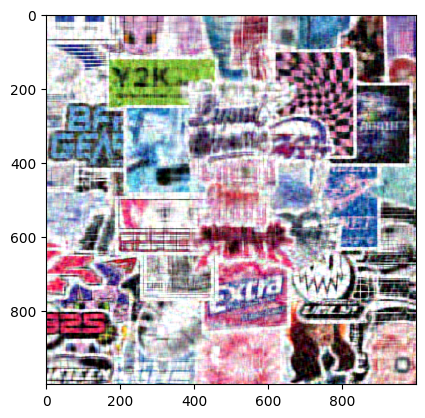

max_iter=10: средняя ошибка 23.73128197331501%
max_iter=10: ошибка R 23.37%
max_iter=10: ошибка G 25.04%
max_iter=10: ошибка B 22.78%


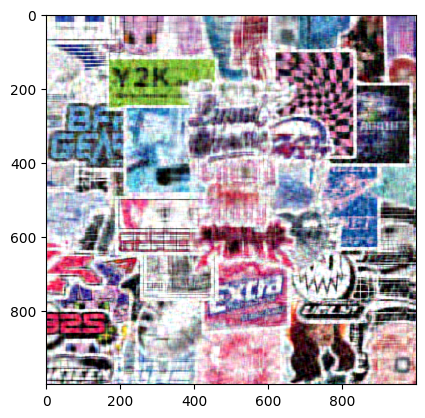

max_iter=50: средняя ошибка 23.698254407215586%
max_iter=50: ошибка R 23.36%
max_iter=50: ошибка G 25.00%
max_iter=50: ошибка B 22.74%


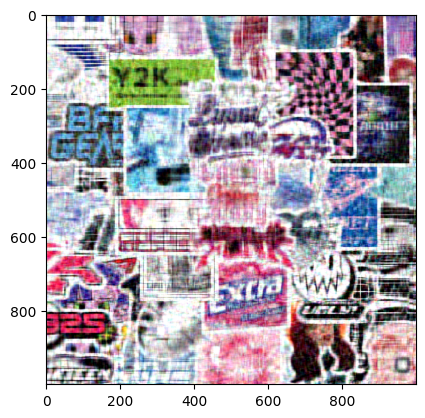

max_iter=100: средняя ошибка 23.696088008997467%
max_iter=100: ошибка R 23.36%
max_iter=100: ошибка G 25.00%
max_iter=100: ошибка B 22.74%


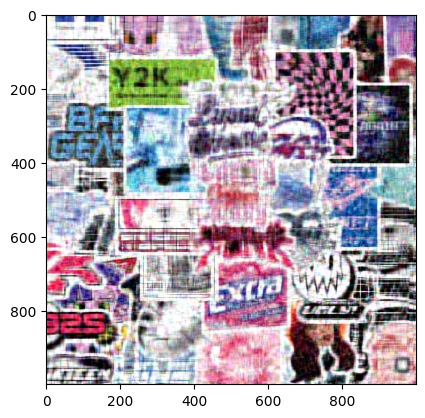

max_iter=500: средняя ошибка 23.69597175909311%
max_iter=500: ошибка R 23.36%
max_iter=500: ошибка G 25.00%
max_iter=500: ошибка B 22.74%


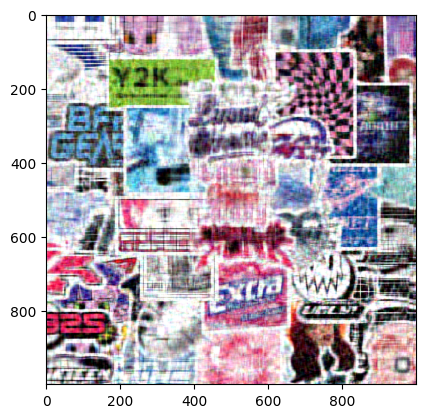

In [283]:
img = image.imread('C:\\Users\\Я\\Desktop\\Чма\\Чмалаб2\\pic.jpeg')
N_c = [1, 5, 10, 50, 100, 500] # точность проработки
plt.imshow(img)
plt.show()
errors=[]
num_components = 35 #количество итераций или шагов, 
#которые требуется выполнить для нахождения наиболее значимого
#сингулярного значения и соответствующих сингулярных векторов или ширина охвата

R,G,B = img[:,:,0]/0xff,img[:,:,1]/0xff,img[:,:,2]/0xff

#R_U, R_S, R_VT = np.linalg.svd(R)
#G_U, G_S, G_VT = np.linalg.svd(G)
#B_U, B_S, B_VT = np.linalg.svd(B)
relative_rank = 0.3
max_rank = 1 #степенной метод используетт только первую сингулярную компоненту 
for i in N_c:
    R_U, R_S, R_VT = power_method_svd(R, num_components, i)
    G_U, G_S, G_VT = power_method_svd(G, num_components, i)
    B_U, B_S, B_VT = power_method_svd(B, num_components, i)
    R_restored = read_from_shrinked(R_U, R_S, R_VT, num_components)
    G_restored = read_from_shrinked(G_U, G_S, G_VT, num_components)
    B_restored = read_from_shrinked(B_U, B_S, B_VT, num_components)
    restored_float = np.dstack((R_restored, G_restored, B_restored))
    img_restored = np.clip(np.dstack((R_restored, G_restored, B_restored)), 0, 1)

    error_R = calculate_reconstruction_error(R, R_restored)
    error_G = calculate_reconstruction_error(G, G_restored)
    error_b = calculate_reconstruction_error(B, B_restored)
    print(f"max_iter={i}: средняя ошибка {(error_R+error_b+error_G)/3}%")
    print(f"max_iter={i}: ошибка R {error_R:.2f}%")
    print(f"max_iter={i}: ошибка G {error_G:.2f}%")
    print(f"max_iter={i}: ошибка B {error_b:.2f}%")

    plt.imshow(img_restored)
    plt.show()

Выше можно заметить, что после определенной степени параметр перестает влиять(как видно на примере с 50 и 100 итерациями) и tol достигается меньшим количеством степеней. Это лучше видно при меньшем количестве компонент

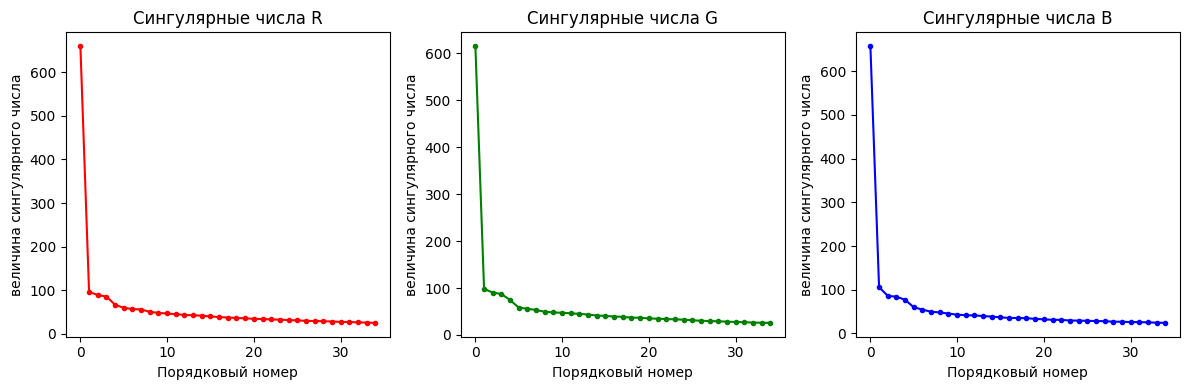

In [284]:
# Графики
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(R_S, 'r.-')
plt.title('Сингулярные числа R')
plt.xlabel('Порядковый номер')
plt.ylabel('величина сингулярного числа')

plt.subplot(1, 3, 2)
plt.plot(G_S, 'g.-')
plt.title('Сингулярные числа G')
plt.xlabel('Порядковый номер')
plt.ylabel('величина сингулярного числа')

plt.subplot(1, 3, 3)
plt.plot(B_S, 'b.-')
plt.title('Сингулярные числа B')
plt.xlabel('Порядковый номер')
plt.ylabel('величина сингулярного числа')

plt.tight_layout()
plt.show()


Большинство информации содержится в первых компонентах(вообще в самой первой больше всего), тк мы видим, что величина сингулярного числа резко уменьшается. Плавный хвост показывает, что остальные значения отвечают за детали, но особой роли не играют

Метод вращений Якоби является классическим и эффективным способом нахождения собственных значений и векторов для симметричных матриц. Он применим в задачах, где важна точность и интерпретируемость собственных значений и векторов, но его использование ограничено большими матрицами, для которых более эффективны другие методы, такие как QR-разложение.

Формализация алгоритма:
1. Пусть A — симметричная матрица размера n x n.
2. Инициализировать матрицу V = I (единичная), которая будет хранить собственные векторы.
3. Пока не достигнута сходимость:
    - Найти индексы (i, j) с наибольшим по модулю внедиагональным элементом A[i,j].
    - Вычислить угол θ для зануления A[i,j].
    - Построить матрицу вращения G.
    - Обновить A как GᵗAG и V как VG.
4. По завершении:
    - Диагональ A содержит собственные значения.
    - Столбцы V — собственные векторы.

Преимущества:
- Простая реализация.
- Хорошо работает для симметричных матриц.
- Гарантирует ортогональность собственных векторов.

Недостатки:
- Медленный на больших матрицах.
- Может требовать много итераций для матриц с близкими по значению собственными числами.


In [285]:
def jacobi_eigenvalues(A, tol=1e-10, max_iter=100):
    n = A.shape[0]
    V = np.eye(n)
    for _ in range(max_iter):
        #наибольший внедиагональный
        off_diagonal = np.triu(np.abs(A), 1)
        i, j = divmod(np.argmax(off_diagonal), n)
        if A[i, j] == 0 or np.abs(A[i, j]) < tol:
            break
        #угол
        if A[i, i] == A[j, j]:
            theta = np.pi / 4
        else:
            theta = 0.5 * np.arctan2(2 * A[i, j], A[j, j] - A[i, i])
        
        c, s = np.cos(theta), np.sin(theta)

        # Обновим A
        for k in range(n):
            if k != i and k != j:
                A_ik, A_jk = A[i, k], A[j, k]
                A[i, k] = c * A_ik - s * A_jk
                A[j, k] = s * A_ik + c * A_jk
                A[k, i], A[k, j] = A[i, k], A[j, k]
        A_ii = A[i, i]
        A_jj = A[j, j]
        A[i, i] = c**2 * A_ii - 2 * s * c * A[i, j] + s**2 * A_jj
        A[j, j] = s**2 * A_ii + 2 * s * c * A[i, j] + c**2 * A_jj
        A[i, j] = A[j, i] = 0.0

    eigenvalues = np.diag(A)
    return np.sort(np.sqrt(eigenvalues))[::-1]


In [286]:
R_channel = R
ATA = R_channel.T @ R_channel
sigma_jacobi = jacobi_eigenvalues(ATA)

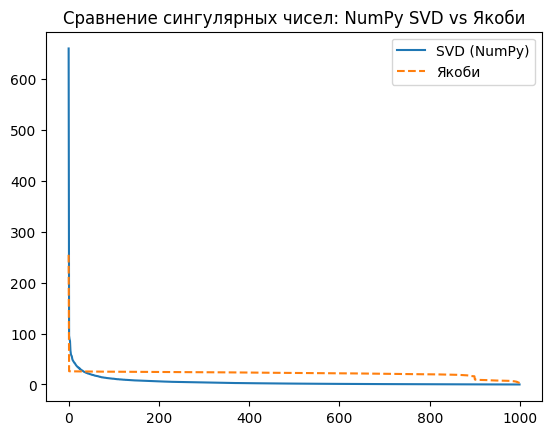

In [287]:
_, S_numpy, _ = power_method_svd(R, 1000, 100)

#_, S_numpy, _ = np.linalg.svd(R_channel, full_matrices=False)

plt.plot(S_numpy, label='SVD (NumPy)')
plt.plot(sigma_jacobi, label='Якоби', linestyle='--')
plt.legend()
plt.title("Сравнение сингулярных чисел: NumPy SVD vs Якоби")
plt.show()


Заметно, что сингулярные числа, вычесленные методом якоби, выглядят странно, связано это с тем, что у нулевого по счету числа самое большое сингулярное число, как и предполагалось выше, что объясняет наше предположение

In [288]:
print(R_channel.T @ R_channel)

[[752.22242215 752.59418685 747.40565936 ... 472.72349097 493.84095348
  510.86059208]
 [752.59418685 760.55747789 757.10303729 ... 475.87080354 498.38780469
  516.69603998]
 [747.40565936 757.10303729 758.98691273 ... 476.07566321 498.33590158
  516.91487889]
 ...
 [472.72349097 475.87080354 476.07566321 ... 452.92699731 450.80925798
  444.53091888]
 [493.84095348 498.38780469 498.33590158 ... 450.80925798 475.79192618
  474.51377163]
 [510.86059208 516.69603998 516.91487889 ... 444.53091888 474.51377163
  498.94658977]]


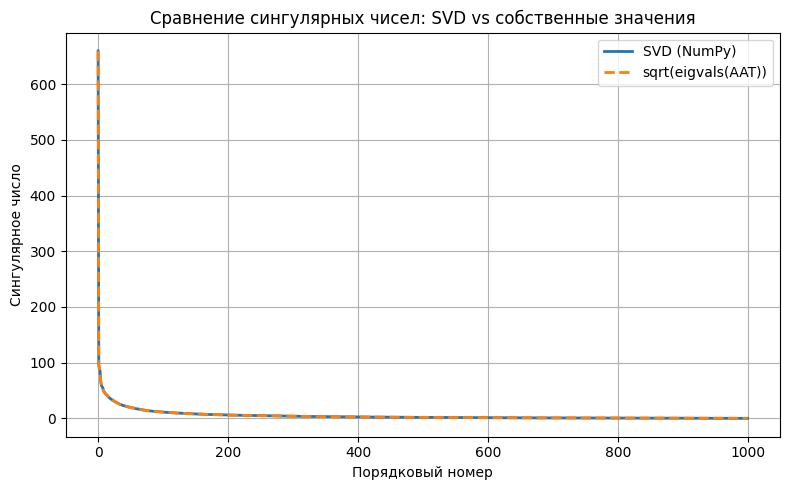

In [289]:
# 1. Нормализуем R-канал
R = img[:, :, 0]
R_channel = R.astype(float) / 255.0

# 2. NumPy SVD
_, S_numpy, _ = np.linalg.svd(R_channel, full_matrices=False)

# 3. Собственные значения A A^T
AAT = R_channel @ R_channel.T
eigvals = np.linalg.eigvalsh(AAT)
eigvals = np.clip(eigvals, 0, None)  # обрезаем отрицательные (если из-за погрешности)
S_from_eig = np.sqrt(np.sort(eigvals)[::-1])  # сингулярные числа

# 4. График
plt.figure(figsize=(8, 5))
plt.plot(S_numpy, label='SVD (NumPy)', linewidth=2)
plt.plot(S_from_eig, '--', label='sqrt(eigvals(AAT))', linewidth=2)
plt.title("Сравнение сингулярных чисел: SVD vs собственные значения")
plt.xlabel("Порядковый номер")
plt.ylabel("Сингулярное число")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Статистика каналов:
R: mean=164.86, std=88.34
G: mean=154.01, std=88.41
B: mean=164.94, std=85.34
Минимальное число сингулярных чисел для 80% энергии: k = 256


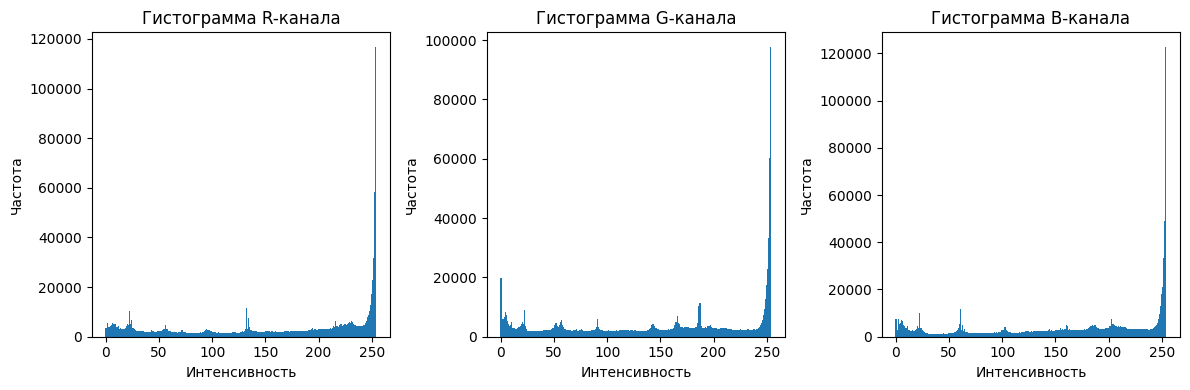

In [ ]:
def analyze_image(img_input, energy_threshold=0.9, plot_histograms=True):
    """
    Анализ изображения: гистограммы глубины цвета, статистики распределения и подбор числа сингулярных чисел.

    Аргументы:
        img_input: путь к файлу или numpy-массив HxWx3 (значения 0-255).
        energy_threshold: доля энергии (суммы сингулярных значений), которую нужно сохранить.
        plot_histograms: рисовать ли гистограммы каналов.

    Возвращает:
        dict с mean, std для каждого канала, k_singular (минимальное k для energy_threshold), и сами гистограммы.
    """
    if isinstance(img_input, str):
        img = image.imread(img_input)
        if img.dtype == np.float32 or img.dtype == np.float64:
            img = (img * 255).astype(np.uint8)
    else:
        img = img_input.astype(np.uint8)
    R = img[:, :, 0].astype(float)
    G = img[:, :, 1].astype(float)
    B = img[:, :, 2].astype(float)

    stats = {}
    histograms = {}
    for name, channel in [('R', R), ('G', G), ('B', B)]:
        counts, bins = np.histogram(channel.ravel(), bins=256, range=(0, 255))
        mean = channel.mean()
        std = channel.std()
        stats[name] = {'mean': mean, 'std': std}
        histograms[name] = (counts, bins)
    gray = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])  # преобразование в яркость
    A = gray / 255.0
    # вычисляем сингулярные значения
    _, S, _ = np.linalg.svd(A, full_matrices=False)
    total_energy = np.sum(S)
    cum_energy = np.cumsum(S)
    # минимальное k, при котором накопленная энергия >= threshold
    k_singular = np.searchsorted(cum_energy, energy_threshold * total_energy) + 1
    print("Статистика каналов:")
    for c in ['R', 'G', 'B']:
        print(f"{c}: mean={stats[c]['mean']:.2f}, std={stats[c]['std']:.2f}")
    print(f"Минимальное число сингулярных чисел для {energy_threshold*100:.0f}% энергии: k = {k_singular}")
    if plot_histograms:
        plt.figure(figsize=(12, 4))
        for i, c in enumerate(['R', 'G', 'B'], 1):
            counts, bins = histograms[c]
            plt.subplot(1, 3, i)
            plt.bar(bins[:-1], counts, width=1)
            plt.title(f"Гистограмма {c}-канала")
            plt.xlabel("Интенсивность")
            plt.ylabel("Частота")
        plt.tight_layout()
        plt.show()

    return {'stats': stats, 'k_singular': k_singular, 'histograms': histograms}

results = analyze_image('C:\\Users\\Я\\Desktop\\Чма\\Чмалаб2\\pic.jpeg', energy_threshold=0.8)
